# Customer Churn Analysis

I'm working with a Telco customer dataset (around 7,000 customers, over 30 columns) to see if I can predict who's likely to cancel their service. The company already tracks some extra stuff like a churn score and a lifetime value estimate, so part of this is figuring out which of those columns are fair to use and which ones basically hand the model the answer.

By the end, I want a model that catches likely churners well enough to be useful for a retention campaign  and I want to actually understand and be able to explain why it's flagging the customers it flags, not just report a score.


## Getting started
Loading the libraries I'll need and reading in the raw file.


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV ,cross_val_score, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
import pickle
import warnings
warnings.filterwarnings("ignore")

In [152]:
df = pd.read_excel("Telco_customer_churn.xlsx")
print(f"dataframe size: {df.shape}" )

dataframe size: (7043, 33)


## First look around
Before doing anything else, I want a feel for what I'm working with how many rows and columns, whether anything's duplicated, and what the numbers roughly look like.


In [153]:
df.head()

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [156]:
df.describe()

        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000000     5.000000  2003.000000  
25%          35.500000     0.00

## Wait, are some of these columns cheating?
A few columns bother me: Churn Reason, Churn Score, and CLTV. Churn Reason only exists for people who already left, so a brand-new customer wouldn't have one yet using it would basically be feeding the model the answer ahead of time. Churn Score looks like it's the company's own prediction for the exact same thing I'm trying to predict, so training on it would just be circular. I'm not as sure about CLTV, so instead of assuming, I'll check what the data actually shows before deciding.


In [157]:
df[df['Churn Reason'].isnull()]['Churn Label'].value_counts()

Churn Label
No    5174
Name: count, dtype: int64

In [158]:
df.groupby('Churn Label')['Churn Score'].describe() 

              count       mean        std   min   25%   50%   75%    max
Churn Label                                                             
No           5174.0  50.098183  17.702277   5.0  35.0  50.0  66.0   80.0
Yes          1869.0  82.510433  10.328570  65.0  74.0  82.0  91.0  100.0

In [159]:
df[['Churn Score','Churn Label']].head(20)

    Churn Score Churn Label
0            86         Yes
1            67         Yes
2            86         Yes
3            84         Yes
4            89         Yes
5            78         Yes
6           100         Yes
7            92         Yes
8            77         Yes
9            97         Yes
10           74         Yes
11           66         Yes
12           65         Yes
13           70         Yes
14           90         Yes
15           82         Yes
16           69         Yes
17           81         Yes
18           96         Yes
19           87         Yes

In [160]:
df.groupby('Churn Score')['Churn Label'].value_counts().tail(20)

Churn Score  Churn Label
81           Yes            56
82           Yes            66
83           Yes            59
84           Yes            49
85           Yes            50
86           Yes            50
87           Yes            65
88           Yes            33
89           Yes            59
90           Yes            64
91           Yes            45
92           Yes            48
93           Yes            47
94           Yes            46
95           Yes            43
96           Yes            52
97           Yes            64
98           Yes            50
99           Yes            54
100          Yes            50
Name: count, dtype: int64

## Which columns are basically useless?
A handful of columns — customer ID, country, zip code, that kind of thing  either never change across the whole dataset or have so many unique values that a model couldn't learn anything meaningful from them. Checking how many distinct values each one has tells me what to drop later.


In [161]:
for col in ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code']:
    print(col, df[col].nunique())

CustomerID 7043
Count 1
Country 1
State 1
City 1129
Zip Code 1652


In [162]:
df.groupby('Churn Label')['CLTV'].describe()

              count         mean          std     min      25%     50%  \
Churn Label                                                              
No           5174.0  4490.921337  1167.703198  2003.0  3643.75  4620.0   
Yes          1869.0  4149.414660  1189.370707  2003.0  3101.00  4238.0   

                 75%     max  
Churn Label                   
No           5434.75  6500.0  
Yes          5166.00  6484.0  

## Sorting out a messy column
Total Charges is supposed to be numeric, but a chunk of it is loading in as text. Rather than just force-converting it and moving on, I wanted to know why  turns out it's new customers with zero months of tenure who haven't been billed yet. So filling those in as 0 actually makes sense.


In [163]:
print(f"{df['Total Charges'].apply(type).value_counts()}")

Total Charges
<class 'float'>    6708
<class 'int'>       324
<class 'str'>        11
Name: count, dtype: int64


In [164]:
df[df['Total Charges'].apply(type) == str]

      CustomerID  Count        Country       State            City  Zip Code  \
2234  4472-LVYGI      1  United States  California  San Bernardino     92408   
2438  3115-CZMZD      1  United States  California    Independence     93526   
2568  5709-LVOEQ      1  United States  California       San Mateo     94401   
2667  4367-NUYAO      1  United States  California       Cupertino     95014   
2856  1371-DWPAZ      1  United States  California        Redcrest     95569   
4331  7644-OMVMY      1  United States  California     Los Angeles     90029   
4687  3213-VVOLG      1  United States  California        Sun City     92585   
5104  2520-SGTTA      1  United States  California      Ben Lomond     95005   
5719  2923-ARZLG      1  United States  California        La Verne     91750   
6772  4075-WKNIU      1  United States  California            Bell     90201   
6840  2775-SEFEE      1  United States  California      Wilmington     90744   

                    Lat Long   Latitude

In [165]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print(f"Missing values in Total Charges: {df['Total Charges'].isnull().sum()}")

Missing values in Total Charges: 11


In [166]:
df['Total Charges'] = df['Total Charges'].fillna(0)
print(df['Total Charges'].dtype)
print(f"{df['Total Charges'].apply(type).value_counts()}")

float64
Total Charges
<class 'float'>    7043
Name: count, dtype: int64


## Clearing out what I don't need
Now that I've flagged which columns leak the answer, which are dead weight, and which are just IDs or location noise, I'm dropping all of them in one go.


In [167]:
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Churn Reason', 'Churn Score','Churn Label','Lat Long','Latitude',	'Longitude']

df = df.drop(columns=drop_cols,errors='ignore')

df.shape

(7043, 21)

In [168]:
df[df['Tenure Months'] == 0]['Total Charges'].unique()

array([0.])

## Checking my assumptions against the data
Before jumping into modeling, I want to sanity-check a couple of hunches  that contract length and internet type probably matter for churn  and actually look at whether the data backs that up, instead of just assuming I'm right.


In [169]:
df.groupby('Internet Service')[['Churn Value','Monthly Charges']].describe()

                 Churn Value                                               \
                       count      mean       std  min  25%  50%  75%  max   
Internet Service                                                            
DSL                   2421.0  0.189591  0.392058  0.0  0.0  0.0  0.0  1.0   
Fiber optic           3096.0  0.418928  0.493463  0.0  0.0  0.0  1.0  1.0   
No                    1526.0  0.074050  0.261938  0.0  0.0  0.0  0.0  1.0   

                 Monthly Charges                                              \
                           count       mean        std    min    25%     50%   
Internet Service                                                               
DSL                       2421.0  58.102169  16.259522  23.45  46.20  56.150   
Fiber optic               3096.0  91.500129  12.663039  67.75  80.55  91.675   
No                        1526.0  21.079194   2.164221  18.25  19.70  20.150   

                                  
                     

In [170]:
df.groupby('Contract')['Churn Value'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

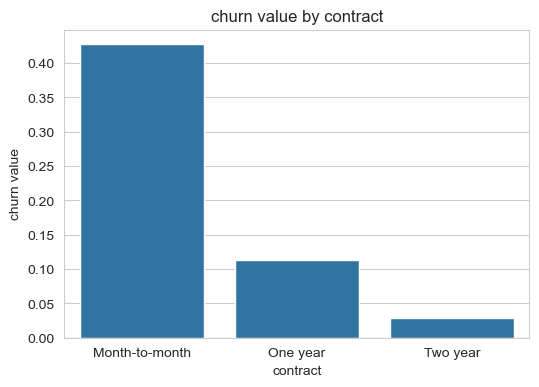

In [171]:
churn_by_contract = df.groupby('Contract')['Churn Value'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data= churn_by_contract,x='Contract',y='Churn Value')
plt.title('churn value by contract')
plt.xlabel('contract')
plt.ylabel('churn value')
plt.show()

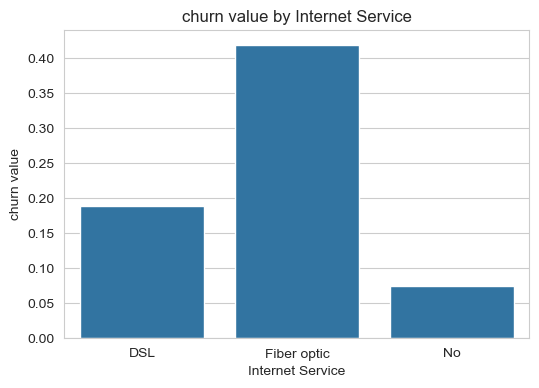

In [172]:
churn_by_contract = df.groupby('Internet Service')['Churn Value'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data= churn_by_contract,x='Internet Service',y='Churn Value')
plt.title('churn value by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('churn value')
plt.show()

## Splitting the data before touching anything else
I'm splitting into training and test sets now, before any scaling or encoding happens. That way the test set stays untouched and gives me an honest read on how the model would actually do on customers it hasn't seen.


In [173]:
y = df['Churn Value']
X = df.drop(columns=['Churn Value'])

In [174]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Getting everything into numbers
Models need numbers, not text, so the categorical columns get converted and the numeric ones get put on a similar scale. Contract gets special treatment here, since "month-to-month," "one year," and "two year" actually have a natural order to them  unlike something like internet type, where none of the options are "more" than another.


In [175]:
from sklearn.preprocessing import StandardScaler
ordinal_cols = ['Contract']
contract_categories = [['Month-to-month', 'One year', 'Two year']]

categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category']).columns 
    if col not in ['Contract', 'Churn Value']
]
num_cols = ['Monthly Charges', 'Total Charges', 'CLTV', 'Tenure Months']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=contract_categories), ordinal_cols),
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('scale', StandardScaler(),num_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


In [176]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [177]:
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)
print(f'X_train shape: {X_train_final.shape}')
print(f'X_test: {X_test_final.shape}')
print(y_train.value_counts(normalize=True))


X_train shape: (5634, 30)
X_test: (1409, 30)
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## Balancing out the churners
Only around 1 in 4 customers in this dataset actually churned, so a lazy model could get decent-looking accuracy just by guessing "stays" every time. I'm using SMOTE to generate some synthetic churn examples so the model is forced to actually learn what churn looks like. I'm also careful to only do this inside each training fold, so none of that synthetic data quietly leaks into the checks I use to judge the model.


In [178]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final,y_train)
print(f'X_train_resampled shape: {X_train_resampled.shape}')
print(y_train_resampled.value_counts())

X_train_resampled shape: (8278, 30)
Churn Value
0    4139
1    4139
Name: count, dtype: int64


## Trying out a few different models
Instead of committing to one algorithm up front, I ran five common ones — logistic regression, decision tree, random forest, SVC, and XGBoost through the same cross-validation setup and compared how they each did on accuracy, precision, recall, F1, and ROC-AUC.


In [179]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = {}
for name, model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    scores = cross_validate(pipe, X_train_final, y_train, cv=cv, scoring=scoring)
    results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}
results_df = pd.DataFrame(results).T
results_df

                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.764113   0.537416  0.798662  0.642311  0.858238
Decision Tree        0.732695   0.496597  0.561873  0.527179  0.678134
Random Forest        0.799612   0.622166  0.623411  0.622485  0.845638
SVC                  0.773342   0.552872  0.761204  0.640128  0.850619
XGBoost              0.785057   0.597269  0.581271  0.588805  0.839357

## Deciding what actually matters here
Accuracy isn't really the right thing to chase in this case. If the model misses someone who's about to leave, that's a real loss lost revenue plus whatever it costs to win a new customer later. If it wrongly flags someone who was never going to leave, worst case they get an email offer they didn't need. So I'd rather have a model that catches more real churners, even if that means more false alarms along the way. That's why I picked the model based on recall rather than overall accuracy  even though something like random forest looks better if you only glance at accuracy.


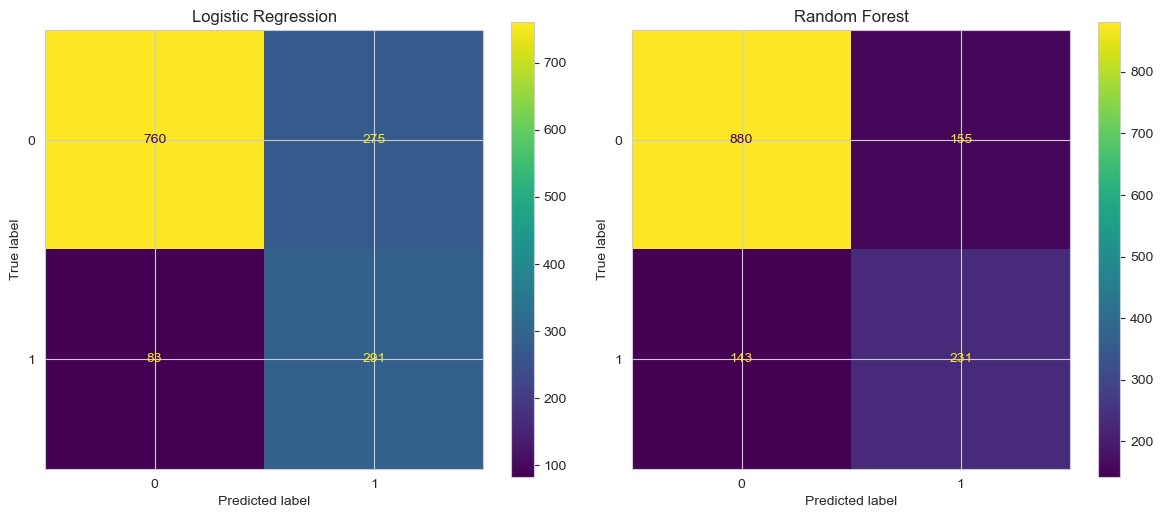

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42))
]):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    pipe.fit(X_train_final, y_train)
    y_pred = pipe.predict(X_test_final)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Fine-tuning logistic regression
Logistic regression came out ahead once recall was the priority, so I tuned its settings how much regularization to apply, and which kind directly against recall, since that's the thing I actually care about, not accuracy.


In [181]:
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']  # liblinear supports both l1 and l2
}

pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

grid_search = GridSearchCV(
    pipe, param_grid, scoring='recall', cv=cv, n_jobs=-1
)
grid_search.fit(X_train_final, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV recall:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_final)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

Best params: {'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV recall: 0.8247491638795987
              precision    recall  f1-score   support

           0       0.91      0.70      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



In [182]:
cm = confusion_matrix(y_test, y_pred_tuned)
print(cm)

[[728 307]
 [ 68 306]]


## So what is the model actually keying in on?
Logistic regression assigns each feature a coefficient, and reading it is fairly simple: a positive number means more of that feature (or being in that category) pushes someone toward churning, a negative number pushes them toward staying, and the bigger the number, the stronger that pull. A bunch of features ended up at zero the tuning process decided they weren't pulling their weight and effectively turned them off, so those get ignored. What's left standing out are contract type, how long someone's been a customer, their monthly bill, and whether they have dependents. Those line up with what I noticed earlier just by eyeballing the data, which is a good sign the model is picking up on something real rather than noise.


In [183]:
coefs = pd.Series(
    best_model.named_steps['clf'].coef_[0],
    index=feature_names
).sort_values()

print(coefs[coefs != 0])

Dependents_Yes                    -1.116622
Contract                          -0.803633
Tenure Months                     -0.592374
Online Security_Yes               -0.158566
Tech Support_Yes                  -0.099515
Paperless Billing_Yes              0.203883
Internet Service_Fiber optic       0.222735
Payment Method_Electronic check    0.310010
Monthly Charges                    0.473406
dtype: float64


## So what should the business actually do with this?
Putting it all together: the customers most likely to churn are on month-to-month contracts, haven't been around long, are paying more per month, and don't have dependents. People paying by electronic check or using fibre internet also show up as riskier. Of the customers in the test set who actually left, this model catches about 82% of them (306 out of 374)  but it also wrongly flags 307 loyal customers who were never going to leave. I'm okay with that trade-off here: missing a real churner costs the company a customer and the cost of replacing them, while a wrong flag just costs a small offer or email nobody needed. For a retention campaign, catching more of the real churners is worth some wasted outreach.


## Saving everything for later
Last step saving the tuned model and the preprocessing pipeline to disk, so I can reuse them on new customers down the line without redoing all of this from scratch.


In [184]:
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)